# ***No-Churn_Telecom***



No-Churn Telecom is a well-established telecommunications provider in Europe, operating successfully for over a decade. With a strong customer base and a history of competitive offerings, the company has built a solid reputation in the industry. However, recent market dynamics and the entry of new players have made the telecom landscape increasingly competitive, prompting No-Churn to explore advanced solutions to maintain its leadership and customer loyalty.


> **Business Problem**                                        
Despite initiatives like tariff reductions and promotional offers, No-Churn Telecom continues to experience a customer churn rate exceeding 10%. This indicates that many customers are still choosing to switch to competitors, highlighting a significant challenge in customer retention. Understanding and predicting which customers are at risk of churning has become critical for the company to implement timely and targeted retention strategies.

This project focuses on leveraging machine learning techniques to predict customer churn and support proactive retention efforts. The models developed include **Decision Tree, Random Forest, and XGBoost classifiers**. Each model was trained and evaluated to identify customers likely to churn based on their behavior and usage patterns. After rigorous evaluation, the **XGBoost model** demonstrated superior performance with an accuracy of 93.83% (0.938312), making it the most effective model for solving the churn prediction problem. The project involves data preprocessing, exploratory data analysis, feature selection, model training, hyperparameter tuning, and performance evaluation, ultimately providing actionable insights to reduce churn and improve customer retention.







# Domain Analysis
This dataset contains customer information from a telecom company, including usage patterns (call minutes, charges), account details, and service plans. The target variable, Churned, indicates whether a customer has left the service. It is used for predicting customer churn and improving retention strategies.

| Feature                  | Data Type | Description                                                   |
|--------------------------|-----------|---------------------------------------------------------------|
| State                    | object    | Customer location or service state                            |
| Account Length           | int64     | Duration of customer account (in days or months)              |
| Area Code                | int64     | Geographic region code                                        |
| Phone                    | object    | Customer phone number                                         |
| International Plan       | object    | Yes/No indicator for international calling plan               |
| VMail Plan               | object    | Yes/No indicator for voicemail plan                           |
| VMail Message            | int64     | Number of voicemail messages                                  |
| Day Mins                 | float64   | Daytime call minutes                                          |
| Day Calls                | int64     | Number of daytime calls made by each customer                 |
| Day Charge               | float64   | Daytime call charges                                          |
| Eve Mins                 | float64   | Evening call minutes                                          |
| Eve Calls                | int64     | Number of evening calls made by each customer                 |
| Eve Charge               | float64   | Evening call charges                                          |
| Night Mins               | float64   | Nighttime call minutes                                        |
| Night Calls              | int64     | Number of nighttime calls made by each customer               |
| Night Charge             | float64   | Nighttime call charges                                        |
| International Mins       | float64   | International call minutes                                    |
| International Calls      | int64     | Number of international calls made by customer                |
| International Charge     | float64   | International call charges                                    |
| Customer_Service_Calls   | int64     | Number of customer service calls                              |
| Churned                  | object    | Yes/No indicator for customer churn                           |


# Importing Dependencies

In [ ]:
!pip install mysql-connector-python

In [ ]:
!pip install sweetviz

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
import warnings
import sweetviz as viz
warnings.filterwarnings('ignore')
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Making connections to database server
connection=mysql.connector.connect(host = '18.136.157.135',
                                  user='dm_team3',
                                  password='***************',
                                  database='project_telecom')

In [ ]:
# Fetching Records
query = "select * from telecom_churn_data"
output = pd.read_sql(query,connection)
print(output.shape)
output

(4617, 21)


,columns1,columns2,columns3,columns4,columns5,columns6,columns7,columns8,columns9,columns10,columns11,columns12,columns13,columns14,columns15,columns16,columns17,columns18,columns19,columns20,columns21
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.3,3,False.
4613,NM,177,408,343-6820,no,yes,29,189,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


In [ ]:
#Creating CSV File
output.to_csv('churn_data.csv')

In [ ]:
#Load_data
pd.set_option('display.max_columns', None)
data=pd.read_csv("churn_data.csv")
data.head()

,Unnamed: 0,columns1,columns2,columns3,columns4,columns5,columns6,columns7,columns8,columns9,columns10,columns11,columns12,columns13,columns14,columns15,columns16,columns17,columns18,columns19,columns20,columns21
0,0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [ ]:
#dropping irrelevant column
data.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
data.rename(columns={'columns1':'State','columns2':'Account_Length','columns3':'Area_Code','columns4':'Phone','columns5':'International_plan',
                    'columns6':'VMail_Plan','columns7':'Vmail_Message','columns8':'Day_Mins','columns9':'Day_Calls','columns10':'Day_Charge',
                    'columns11':'Eve_Mins','columns12':'Eve_Calls','columns13':'Eve_Charge','columns14':'Night_Mins','columns15':'Night_Calls',
                    'columns16':'Night_Charge','columns17':'International_mins','columns18':'International_calls','columns19':'International Charge',
                    'columns20':'Customer_Service_Calls','columns21':'Churned'},inplace=True)

In [ ]:
data.head()

,State,Account_Length,Area_Code,Phone,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


# Basic Checks

In [ ]:
data.head()

,State,Account_Length,Area_Code,Phone,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [ ]:
data.tail()

,State,Account_Length,Area_Code,Phone,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.
4616,IN,140,415,409-6884,no,no,0,204.7,100,34.80,126.8,107,10.78,202.8,115,9.13,12.1,4,3.27,2,False.


In [ ]:
data.describe()

,Account_Length,Area_Code,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls
count,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000
mean,100.645224,437.046350,7.849903,180.447152,100.054364,30.676576,200.429088,100.179770,17.036703,200.623933,99.944120,9.028185,10.279294,4.433831,2.775926,1.567035
std,39.597194,42.288212,13.592333,53.983540,19.883027,9.177145,50.557001,19.821314,4.297332,50.543616,19.935053,2.274488,2.757361,2.457615,0.744413,1.307019
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,12.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,165.900000,87.000000,14.100000,167.100000,87.000000,7.520000,8.600000,3.000000,2.320000,1.000000
50%,100.000000,415.000000,0.000000,180.000000,100.000000,30.600000,200.800000,101.000000,17.070000,200.800000,100.000000,9.040000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,17.000000,216.800000,113.000000,36.860000,234.000000,114.000000,19.890000,234.900000,113.000000,10.570000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,351.500000,165.000000,59.760000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [ ]:
data.describe(include='O')

,State,Phone,International_plan,VMail_Plan,Churned
count,4617,4617,4617,4617,4617
unique,51,4617,2,2,2
top,WV,409-6884,no,no,False.
freq,149,1,4171,3381,3961


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   4617 non-null   object 
 1   Account_Length          4617 non-null   int64  
 2   Area_Code               4617 non-null   int64  
 3   Phone                   4617 non-null   object 
 4   International_plan      4617 non-null   object 
 5   VMail_Plan              4617 non-null   object 
 6   Vmail_Message           4617 non-null   int64  
 7   Day_Mins                4617 non-null   float64
 8   Day_Calls               4617 non-null   int64  
 9   Day_Charge              4617 non-null   float64
 10  Eve_Mins                4617 non-null   float64
 11  Eve_Calls               4617 non-null   int64  
 12  Eve_Charge              4617 non-null   float64
 13  Night_Mins              4617 non-null   float64
 14  Night_Calls             4617 non-null   

# Exploratory Data Analysis

**Bivariate Analysis**

**Getting categorical variables**

In [ ]:
cat_data=data.select_dtypes(include='O')
cat_data

,State,Phone,International_plan,VMail_Plan,Churned
0,KS,382-4657,no,yes,False.
1,OH,371-7191,no,yes,False.
2,NJ,358-1921,no,no,False.
3,OH,375-9999,yes,no,False.
4,OK,330-6626,yes,no,False.
...,...,...,...,...,...
4612,NY,345-7512,no,yes,False.
4613,NM,343-6820,no,yes,False.
4614,VT,338-4794,no,yes,False.
4615,MI,355-8388,no,yes,False.


In [ ]:
#Getting unique categorical features
for i in cat_data:
    print(i,cat_data[i].unique())
    print(cat_data[i].value_counts())
    print("----------------------------------------------------------------------------------")

State ['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'LA' 'WV' 'IN' 'RI' 'IA' 'MT' 'NY'
 'ID' 'VT' 'VA' 'TX' 'FL' 'CO' 'AZ' 'SC' 'NE' 'WY' 'HI' 'IL' 'NH' 'GA'
 'AK' 'MD' 'AR' 'WI' 'OR' 'MI' 'DE' 'UT' 'CA' 'MN' 'SD' 'NC' 'WA' 'NM'
 'NV' 'DC' 'KY' 'ME' 'MS' 'TN' 'PA' 'CT' 'ND']
State
WV    149
AL    114
MN    112
ID    110
OH    110
VA    109
NY    109
OR    107
WY    106
NJ    106
TX    105
UT    104
WI     99
MI     98
MA     97
KS     96
ME     95
VT     95
MT     92
CT     92
MD     92
NH     91
CO     91
MS     91
KY     90
RI     90
IN     89
WA     89
NV     89
DE     89
FL     85
NM     84
MO     84
NC     83
TN     83
SC     83
DC     82
AZ     81
OK     80
ND     80
IL     79
HI     79
NE     79
GA     77
AR     77
SD     76
LA     73
AK     69
PA     68
IA     65
CA     44
Name: count, dtype: int64
----------------------------------------------------------------------------------
Phone [' 382-4657' ' 371-7191' ' 358-1921' ... ' 338-4794' ' 355-8388'
 ' 409-6884']
Phone
409-6884    1
382-

In [ ]:
categorical_data = [col for col in cat_data.columns if cat_data[col].nunique() < 30]

In [ ]:
categorical_data

['International_plan', 'VMail_Plan', 'Churned']

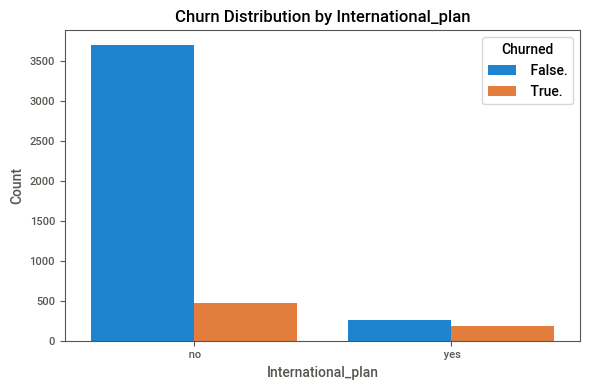

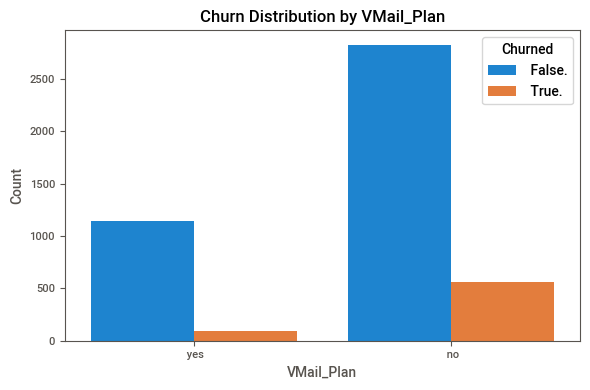

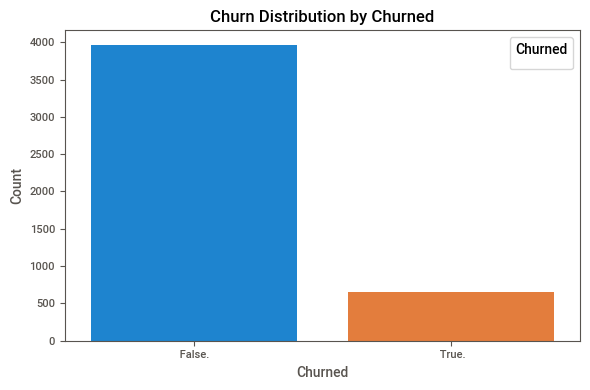

In [ ]:
for col in categorical_data:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=col, hue='Churned')
    plt.title(f'Churn Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Churned')
    plt.tight_layout()
    plt.show()

**Churn Distribution**

<h5>
<details>
<summary>Churn Distribution by International Plan</summary>

- **Majority Lack International Plan:** The vast majority of customers (approximately 3500) do not have an International Plan, indicating it’s not a widely adopted service, which may reflect low demand or poor marketing.  
- **Higher Churn Among Non-International Plan Users:** Of the customers without an International Plan, a significant portion (around 500) have churned, suggesting that the absence of this plan or dissatisfaction with alternatives might contribute to churn.  
- **Lower Overall Churn with International Plan:** Customers with an International Plan show a much lower churn count (around 200 non-churned vs. a small number churned), implying that this plan may enhance retention, possibly due to added value or competitive pricing.  
- **International Plan as a Retention Tool:** The data suggests that offering or promoting the International Plan could reduce churn, especially for customers with international calling needs, as churn is notably lower among its users.  
- **Disproportionate Churn Impact:** The churn rate appears higher relative to the total customer base for those without an International Plan, indicating that this feature might be a differentiating factor in a competitive market, where competitors may offer better international options.  

</details>

<details>
<summary>Churn Distribution by VMail Plan</summary>

- **Majority Lack VMail Plan:** The majority of customers (around 3000) do not have a VMail Plan, which may reflect low adoption or insufficient marketing, potentially leaving a large segment vulnerable to churn.  
- **High Retention with VMail Plan:** Approximately 1000 customers with a VMail Plan (Yes) did not churn (False), and only a small number churned (True), suggesting that the VMail Plan is associated with higher customer retention.  
- **Significant Churn Without VMail Plan:** Around 2500 customers without a VMail Plan (No) did not churn, but a notable portion (around 500) did churn, indicating that the lack of a VMail Plan might contribute to higher churn rates.  
- **VMail Plan as a Retention Factor:** The low churn among VMail Plan subscribers (Yes) compared to non-subscribers (No) implies that offering or promoting the VMail Plan could be an effective strategy to reduce the overall churn rate, which is above 10%.  
- **Potential for Targeted Campaigns:** Customers without a VMail Plan who have churned could be targeted with promotional offers for the plan, as the data suggests a correlation between not having the plan and increased likelihood of leaving for a competitor.  

</details>

<details>
<summary>Churn Distribution by Churned</summary>

- **Large Retained Customer Base:** Approximately 3500 customers have not churned (False), indicating a strong retained customer base despite the competitive market and a churn rate above 10%.  
- **Significant Churn Volume:** Around 500 customers have churned (True), confirming the reported churn rate exceeding 10% and highlighting a notable loss to competitors.  
- **Retention Challenge:** The disparity between non-churned (3500) and churned (500) customers underscores the challenge of retaining the existing customer base amidst new market players.  
- **Opportunity for Intervention:** The substantial number of non-churned customers provides a foundation to implement retention strategies (e.g., personalized offers) to prevent further migration.  
- **Churn Impact Assessment:** The 500 churned customers represent a critical segment to analyze (e.g., using features like Day Calls or CustServ Calls) to identify patterns and develop targeted campaigns to reduce future churn.  

</details>
</h5>

**Separating Numerical columns**

In [ ]:
num_data = data.select_dtypes(include=['int64', 'float64'])
num_data

,Account_Length,Area_Code,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3
4613,177,408,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3
4614,67,408,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1
4615,98,415,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0


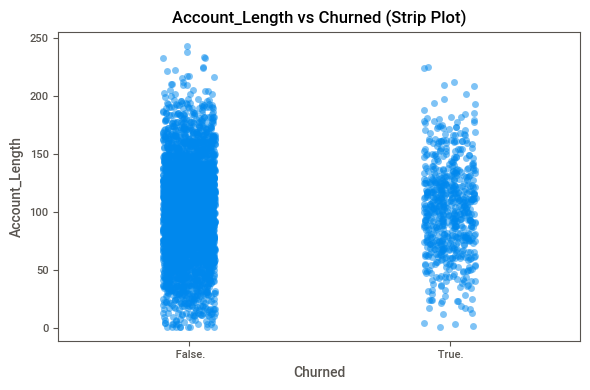

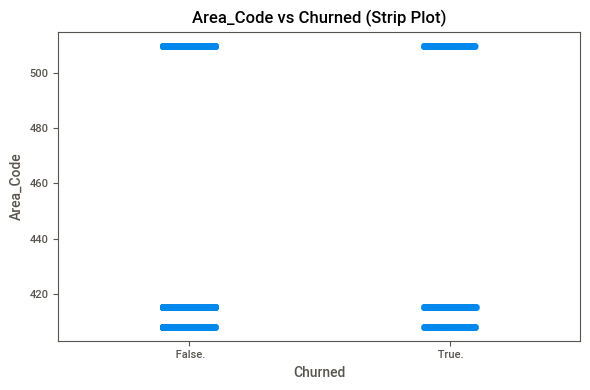

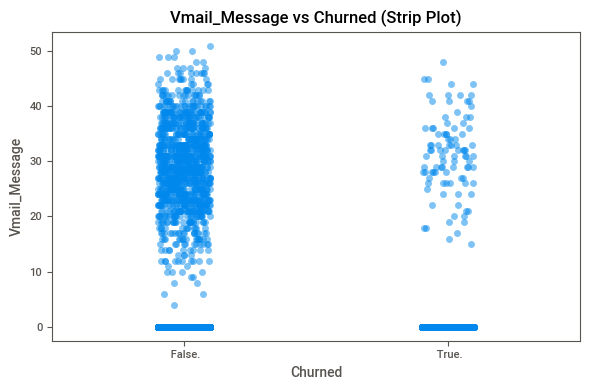

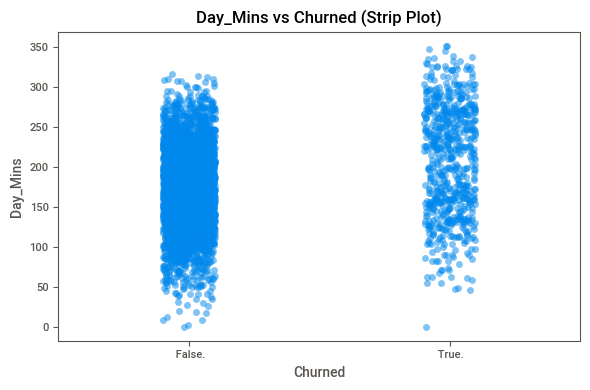

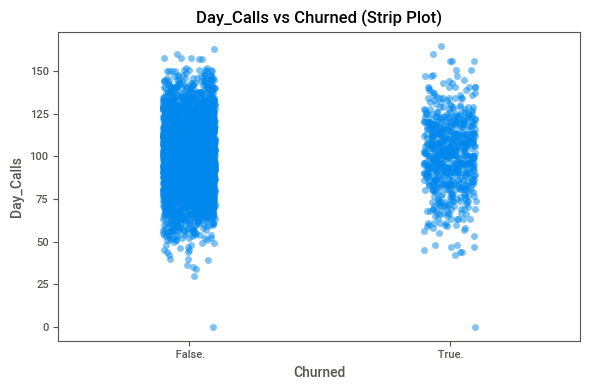

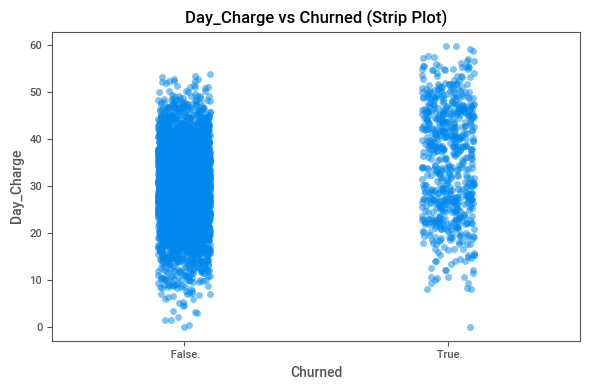

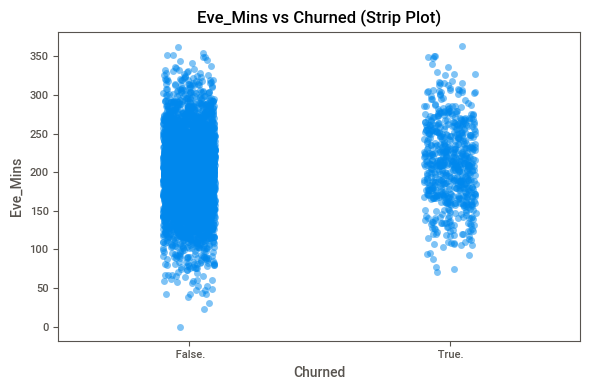

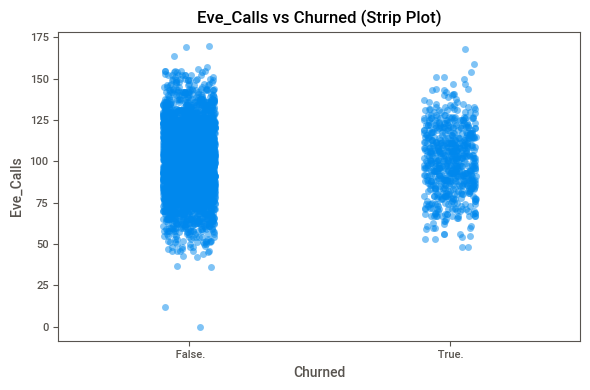

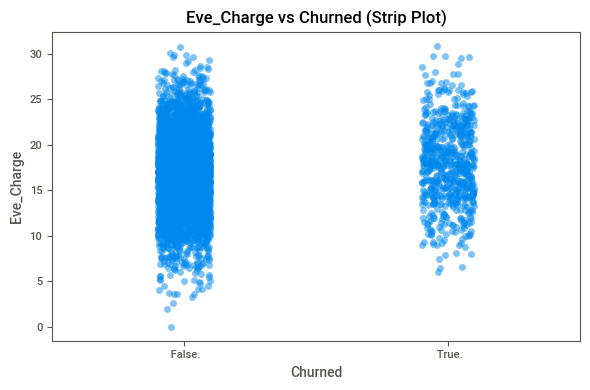

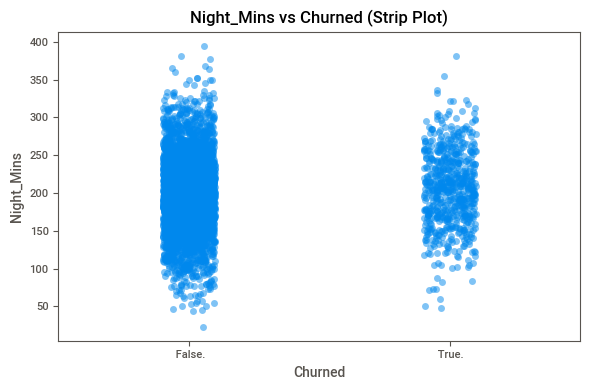

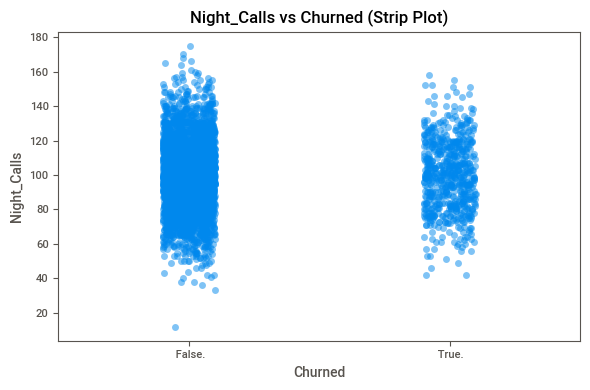

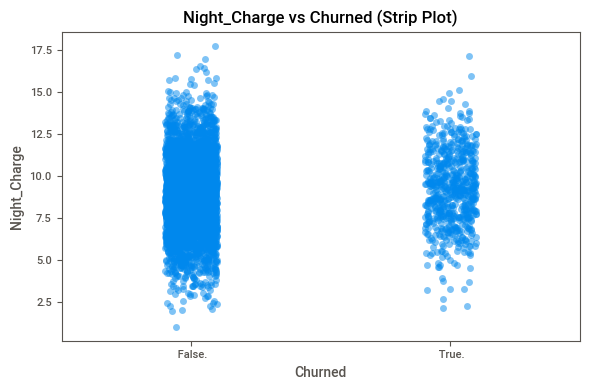

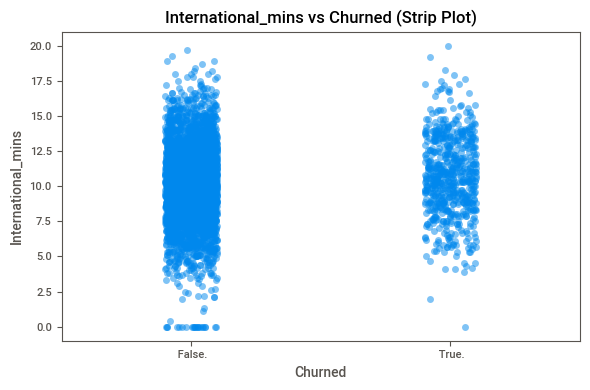

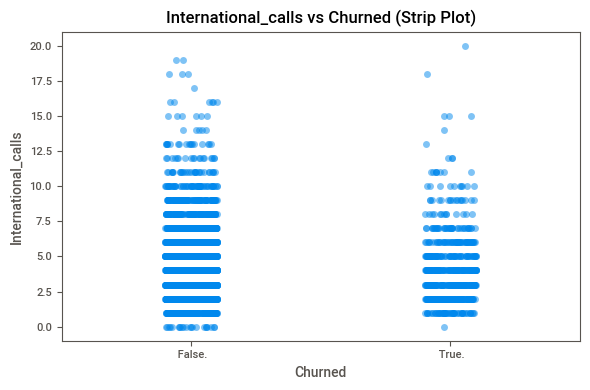

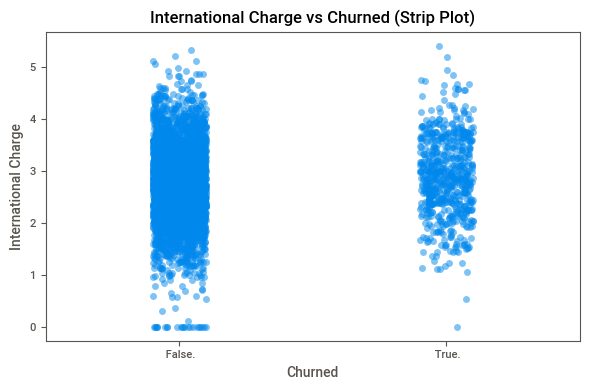

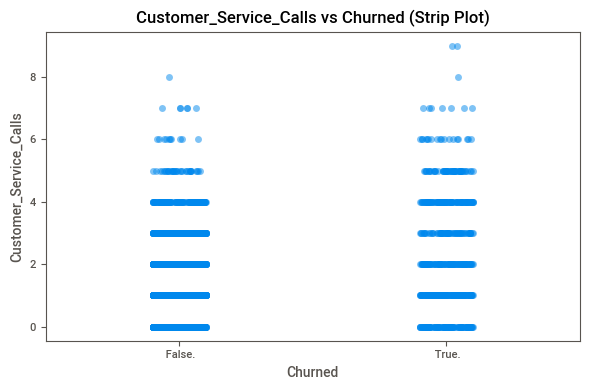

In [ ]:
for col in num_data.columns:
    plt.figure(figsize=(6, 4))
    sns.stripplot(data=data, x='Churned', y=col, jitter=True, alpha=0.5)
    plt.title(f'{col} vs Churned (Strip Plot)')
    plt.xlabel('Churned')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


**Numerical Data Analysis**

<details>
<summary> <b>VMail Vs Churned</b> </summary>
  
- **High VMail Usage Among Non-Churned:** The majority of non-churned customers (False) have VMail_Message values ranging from 0 to 50, with a dense concentration around 0-20, suggesting that active voicemail usage is common among retained customers.
- **Lower VMail Usage Among Churned:** Churned customers (True) also show VMail_Message values up to 50, but the distribution is sparser, with fewer instances above 20, indicating that lower or no voicemail usage might correlate with churn.
- **Zero Usage Common Across Both Groups:** A notable number of both churned and non-churned customers have zero VMail_Message, implying that lack of voicemail usage alone may not directly drive churn but could reflect disengagement with the service.
- **Potential Retention Link with VMail:** The denser spread of higher VMail_Message values (e.g., 10-20) among non-churned customers suggests that encouraging voicemail use (e.g., through promotions or better integration) could enhance retention.
- **Targeted Intervention Opportunity:** Customers with low or zero VMail_Message who have churned could be targeted with campaigns to increase engagement with the VMail Plan, potentially reducing the churn rate above 10% in the competitive market.
</details>

<details>
    <summary> <b>Day_mins vs Churned </b></summary>
    
- **Wide Range of Daytime Usage:** Day_Mins for both churned and non-churned customers range from 0 to approximately 350 minutes, indicating varied usage patterns across the customer base.
- **Similar Usage Distribution:** The strip plot shows a comparable spread of Day_Mins for both False (non-churned) and True (churned) customers, with dense concentrations between 100 and 250 minutes, suggesting that daytime usage alone may not strongly differentiate churn behavior.
- **High Usage Across Both Groups:** Both groups exhibit a significant number of customers with high Day_Mins (e.g., 200-300 minutes), implying that heavy daytime users are present among both retained and lost customers.
- **Targeted Retention Focus:** Customers with high Day_Mins who have churned could be targeted with retention offers (e.g., discounted daytime rates or unlimited plans) to prevent further loss, as this segment appears vulnerable despite high usage.
</details>

<details>
<summary> <b>Day_Calls VS Churned</b> </summary>
    
- **Broad Range of Call Frequency:** Day_Calls for both churned and non-churned customers range from 0 to approximately 150, indicating a wide variety of call frequencies among the customer base.
- **Similar Call Distribution:** The strip plot shows a comparable spread of Day_Calls for both False (non-churned) and True (churned) customers, with a dense concentration between 50 and 100 calls, suggesting that call frequency alone may not be a primary churn driver.
- **High Call Volume Across Groups:** Both groups have a significant number of customers with Day_Calls between 75 and 125, implying that frequent callers are present among both retained and lost customers.
- **Retention Strategy Focus:** Customers with high Day_Calls who have churned could be targeted with retention offers (e.g., flat-rate plans or discounted call packages) to address potential pricing concerns and reduce future churn.
</details>

<details>
    <summary><b> Day_charge vs Churned</b></summary>

 - **Wide Range of Daytime Charges:** Day_Charge for both churned and non-churned customers ranges from 0 to approximately 60, reflecting varied billing amounts based on daytime usage.
 - **Similar Charge Distribution:** The strip plot shows a comparable spread of Day_Charge for both False (non-churned) and True (churned) customers, with a dense concentration between 20 and 40, suggesting that charge levels alone may not strongly differentiate churn behavior.
 - **High Charges Across Both Groups:** Both groups have a significant number of customers with Day_Charge between 30 and 50, indicating that high daytime charges are common among both retained and lost customers.
 - **Potential Churn Driver:** The presence of higher Day_Charge values (e.g., 40-60) among churned customers could suggest that excessive costs relative to usage (e.g., Day_Mins) may drive customers to competitors, contributing to the churn rate above 10%.
 - **Retention Opportunity:** Customers with high Day_Charge who have churned could be targeted with retention strategies such as discounted daytime rates or flexible billing plans to reduce churn and improve customer satisfaction.
</details>

<details>
    <summary><b> Eve_mins VS Churned</b></summary>

- **Broad Range of Evening Usage:** Eve_Mins for both churned and non-churned customers ranges from 0 to approximately 350 minutes, indicating a diverse usage pattern during evening hours across the customer base.
- **Comparable Usage Distribution:** The strip plot shows a similar spread of Eve_Mins for both False (non-churned) and True (churned) customers, with a dense concentration between 100 and 250 minutes, suggesting that evening usage alone may not be a primary churn indicator.
- **High Usage Across Both Groups:** Both groups have a significant number of customers with Eve_Mins between 150 and 300, implying that heavy evening users are present among both retained and lost customers.
- **Retention Strategy Opportunity:** Customers with high Eve_Mins who have churned could be targeted with retention offers, such as discounted evening rates or unlimited evening plans, to address potential pricing concerns and reduce future churn.
</details>

<details>
    <summary><b> Eve_Calls VS Churned</b></summary>

- **Wide Range of Evening Calls:** Eve_Calls for both churned and non-churned customers ranges from 0 to approximately 175, indicating a diverse frequency of evening call activity across the customer base.
- **Similar Call Frequency Distribution:** The strip plot shows a comparable spread of Eve_Calls for both False (non-churned) and True (churned) customers, with a dense concentration between 50 and 125 calls, suggesting that call frequency alone may not be a primary churn driver.
- **High Call Volume Across Groups:** Both groups have a significant number of customers with Eve_Calls between 75 and 150, implying that frequent evening callers are present among both retained and lost customers.
- **Retention Strategy Opportunity:** Customers with high Eve_Calls who have churned could be targeted with retention offers, such as flat-rate evening plans or discounted call packages, to address potential pricing concerns and reduce future churn.  
</details>

<details>
    <summary><b> Eve_Charge VS Churned</b></summary>

- **Higher Evening Charges Correlate with Increased Churn:** The distribution of data points for churned customers (labeled "True") is visibly shifted upwards compared to loyal customers ("False"). This indicates that, on average, customers who leave tend to have higher evening charges. This group might feel they are overpaying or not getting enough value for their expenditure.
- **High-Spending Customers Represent a Significant Churn Risk:** The upper range of the evening charges (approximately >25) shows a notable concentration of churned customers. These are high-value customers based on their evening usage. Their decision to leave suggests that No-Churn's tariffs might not be competitive for heavy users, who may be actively seeking better deals from rival operators.
- **Evening Charge Alone Is Not a Definitive Predictor of Churn:** There is a substantial overlap in evening charges between customers who churn and those who do not, especially in the $10 to $25 range. This means that many customers with similar spending habits have different loyalty outcomes. Therefore, while evening charge is a contributing factor, it must be analyzed alongside other variables (like plan details, customer service interactions, or call patterns) to build an accurate churn prediction model.
- **The Majority of Customers Are Loyal:** The density of the data points under the "False" category is much greater than under the "True" category. This visually confirms that most customers are not churning, which is a positive baseline. The challenge for No-Churn Telecom is to precisely identify the at-risk minority within this large pool of loyal customers.
- **5. Both High and Low Spenders Are Churning:** While high-spenders show a greater tendency to churn, there are also churned customers at the lower end of the evening charge spectrum. The reasons are likely different: high-spenders may leave due to cost, while low-spenders might leave due to a lack of engagement, poor network quality, or finding better basic-tier offers elsewhere. This implies that a "one-size-fits-all" retention strategy will be ineffective; offers should be tailored to different user segments
</details>

<details>
    <summary><b>Night_mins VS Churned</b></summary>

- **Night Usage Is Not a Strong Indicator of Churn:** The most significant insight from this chart is the lack of a clear difference between the two groups. The distribution of night minutes for customers who churned ("True") is visually very similar to the distribution for those who did not churn ("False"). This suggests that the amount of time a customer spends on calls at night has little to no influence on their decision to leave the company.
- **Similar Usage Patterns Across Both Groups:** Both loyal and churned customers exhibit a wide and comparable range of night-time usage, from very low (near 50 minutes) to very high (approaching 400 minutes). The central tendency (the most dense area of points) for both groups also appears to be centered around the same level, roughly 200-250 minutes. This reinforces that typical night usage is not a distinguishing behavior between these two customer segments.
- **Retention Strategies Should Not Focus on Night Minutes:** Since night-time usage does not differentiate churners from loyal customers, any retention strategies based on this metric are unlikely to be effective. For example, offering special discounts on night calls would probably not impact the churn rate, as customers are not leaving due to issues related to their night-time usage or costs.
- **Churn Occurs Across All Levels of Night Usage:** There isn't a specific segment of night-time users (e.g., only very high or very low users) that is churning. Customers are leaving regardless of whether they use their phone a lot or a little during the night. This implies the reasons for churn lie elsewhere—perhaps in pricing for other services, customer support quality, or network performance during peak hours.   
</details>

<details>
    <summary><b>Night_calls VS Churned</b></summary>
    
- **Number of Night Calls Is Not a Driver of Churn:** The most striking feature of this plot is how similar the distributions are for both churned ("True") and loyal ("False") customers. Both groups make a comparable number of calls at night, with a similar range and central tendency (around 100 calls). This strongly indicates that the frequency of night calls has no significant relationship with a customer's decision to churn.
- **Calling Behavior at Night is Consistent Across All Customers:** Whether a customer is loyal or at risk of churning, their night-time calling habits appear to be the same. There are no distinct clusters of high- or low-frequency callers that are more prone to churn. This behavioral consistency suggests that customers are not leaving due to issues related to night-time call access, quality, or frequency.
- **This Metric Is Not Useful for Churn Prediction:** From a data science perspective, "Night_Calls" would be considered a weak feature for a churn prediction model. Since it does not help distinguish between a customer who will stay and one who will leave, it would likely be assigned a very low importance score by a machine learning algorithm. Relying on it would lead to an inaccurate model.
- **Do Not Base Retention Offers on Night Call Frequency:** Any marketing or retention campaign based on the number of night calls would be ineffective and a waste of resources. For example, offering a special plan to customers who make more than 120 night calls per month would target both loyal and churn-risk customers equally, failing to focus on those who actually need an incentive to stay.
- **The Root Cause of Churn Lies in Other Factors:** This analysis, especially when combined with the finding that Night_Mins is also not a predictor, provides a valuable insight through elimination. It tells No-Churn Telecom that the reasons for its 10%+ churn rate are not related to its night-time service. The company should therefore direct its analytical efforts and resources toward other, more impactful variables, such as peak-hour charges (e.g., Eve_Charge), plan features (e.g., VMail_Plan), customer service history, and charges for international calls.
</details>

<details>
    <summary><b>Night_charge VS Churned</b></summary>

- **Night Charges Do Not Influence Customer Churn:** This is the most direct insight from the chart. The distribution of Night_Charge for customers who churned ("True") is nearly identical to that of customers who remained loyal ("False"). Both groups have a similar spread and central point (around $7.5 to $12.5). This indicates that the cost of night-time usage is not a factor in a customer's decision to leave.
- **Night-Time Tariffs Are Likely Not a Source of Dissatisfaction:** Since customers with both low and high night charges are churning at similar rates to loyal customers, it suggests that the pricing for night calls is perceived as fair or is simply not important enough to influence loyalty. If night charges were a problem, we would expect to see the churned customer group showing a shift towards higher charges.
- **All Night-Related Metrics Are Consistently Poor Predictors of Churn:** This finding is consistent with the analyses of Night_Mins and Night_Calls. Since charges are typically calculated from minutes (Charge = Minutes × Rate), it is logical that if Night_Mins is not a predictor of churn, Night_Charge will not be one either. This reinforces the conclusion that night-time service (be it usage, call frequency, or cost) is irrelevant to No-Churn Telecom's churn problem.

</details>

<details>
    <summary><b>International_mins VS Churned</b></summary>

- **International Usage Is Not a Key Driver of Churn:** The most significant observation is the striking similarity between the two distributions. The spread, density, and central point of international minutes for customers who churned ("True") are nearly identical to those for loyal customers ("False"). This indicates that the volume of international calls a customer makes has little to no correlation with their likelihood of churning.
- **A Wide Range of International Usage Exists in Both Groups:** Both loyal and churned customers display a full spectrum of international usage, from zero minutes up to the maximum of 20 minutes. There isn't a specific usage pattern (e.g., very heavy users or non-users) that is disproportionately represented in the churned group. This suggests that neither heavy usage (implying high cost) nor zero usage (implying lack of need for the service) is a primary reason for leaving.
- **Customers with Zero International Usage Are Present in Both Segments:** A distinct line of data points at International_mins = 0 is visible for both loyal and churned customers. While visually, the density of these non-users might seem slightly higher in the loyal ("False") category, the presence in both groups shows that simply not using the international feature does not prevent churn.

</details>

<details>
    <summary><b>International_calls VS Churned</b></summary>

- **Number of International Calls Is Not a Driver of Churn:** The most apparent insight is the strong similarity between the two distributions. Both loyal ("False") and churned ("True") customers make a comparable number of international calls. The range, density, and most frequent values (the darkest horizontal lines) are nearly identical for both groups. This indicates that the frequency of international calls has no significant bearing on a customer's decision to churn.
- **A Significant "Domestic-Only" Segment Exists and Is Also Churning:** A very dense line of data points is visible at International_calls = 0 for both loyal and churned customers. This highlights a large customer segment that does not use the international calling feature at all. The fact that churn is still occurring within this group is a crucial finding—it proves that the reasons for churn are unrelated to international service and must stem from domestic service aspects like plan pricing, network quality, or customer support.
- **Calling Behavior Is Consistent Across All Levels:** The data is discrete (whole numbers of calls), which results in the horizontal lines of dots. For nearly every number of calls made—from 1 to over 15—there are customers who churn and customers who stay. This lack of a clear pattern reinforces that there is no "at-risk" threshold for the number of international calls. A customer making 3 calls is just as likely to stay or leave as a customer making 10 calls.
</details>

<details>
    <summary><b>International_charge VS Churned</b></summary>

- **International Charges Do Not Drive Churn:** This is the clearest insight from the chart. The distribution of international charges for customers who churned ("True") is virtually identical to the distribution for loyal customers ("False"). Both groups have the same range, spread, and central point (around $2.50 - $3.50). This indicates that the cost of international calls is not a factor influencing a customer's decision to leave.
- **International Pricing Is Not a Pain Point:** If the cost of international calls were a reason for churn, one would expect to see the churned customer group shifted towards higher charges. The fact that the distributions are so similar suggests that No-Churn's international tariffs are likely perceived as fair or are simply not a significant consideration for customers when deciding whether to stay or switch providers.
- **A Comprehensive Picture: International Usage Is Not a Churn Factor:** This chart's conclusion is strongly supported by the analyses of International_mins and International_calls. Since charge is a direct function of usage (minutes) and the rate, it is logical that if usage itself is not a predictor, the resulting charge won't be either. This gives No-Churn Telecom a confident, comprehensive view that its entire international service offering (usage, frequency, and cost) is not related to its churn problem.  
</details>

<details>
    <summary><b>Customer_service_calls VS Churned</b></summary>

- **High Number of Customer Service Calls Is a Powerful Predictor of Churn:** This is the most significant insight. There is a clear and dramatic difference between the two groups. While the majority of loyal customers ("False") made between 0 and 3 calls, a large proportion of churned customers ("True") made 4 or more calls. The number of dots for 4, 5, 6, and more calls is substantially higher in the churned category, indicating that frequent contact with customer service is a major red flag for churn.
- **There Is a Clear "Tipping Point" for Customer Frustration:** The data suggests a churn "tipping point" at around 4 customer service calls. Customers who call 0, 1, 2, or 3 times can still be retained. However, once a customer needs to contact support for the fourth time (or more), their likelihood of churning increases drastically. This suggests that by the fourth call, the customer's issue has likely not been resolved, leading to frustration and the decision to leave.
- **This Is a Highly Actionable Insight for Proactive Retention:** This finding provides a clear, data-driven trigger for intervention. No-Churn Telecom should implement a proactive retention strategy:
   - Flag any customer who logs their 3rd service call.
   -  Escalate any customer logging their 4th service call to a specialized retention team immediately.
- **Poor First-Call Resolution Is Likely a Major Problem:** The pattern implies that customers are having to call back multiple times about the same or recurring issues. This points to a potential systemic problem in the customer service department, such as inadequate training, lack of agent empowerment to solve problems, or inefficient processes. Improving the First-Call Resolution (FCR) rate could be a key strategy to reduce churn.
- **Even Satisfied Customers Churn, But Dissatisfied Ones Are a Priority:** It's important to note that some customers churn even with 0 or 1 customer service call. This means that customer service interaction is not the only cause of churn; factors like price, network coverage, or competitor offers also play a role. However, the strong correlation shows that customers with multiple service calls represent a large, identifiable, and highly at-risk segment that must be addressed as a priority.   
    
</details>

# Data Preprocessing

**Checking for null values**


In [ ]:
data.isnull().sum()

,0
State,0
Account_Length,0
Area_Code,0
Phone,0
International_plan,0
VMail_Plan,0
Vmail_Message,0
Day_Mins,0
Day_Calls,0
Day_Charge,0


**No Null-Values are found**

**Checking for outliners**

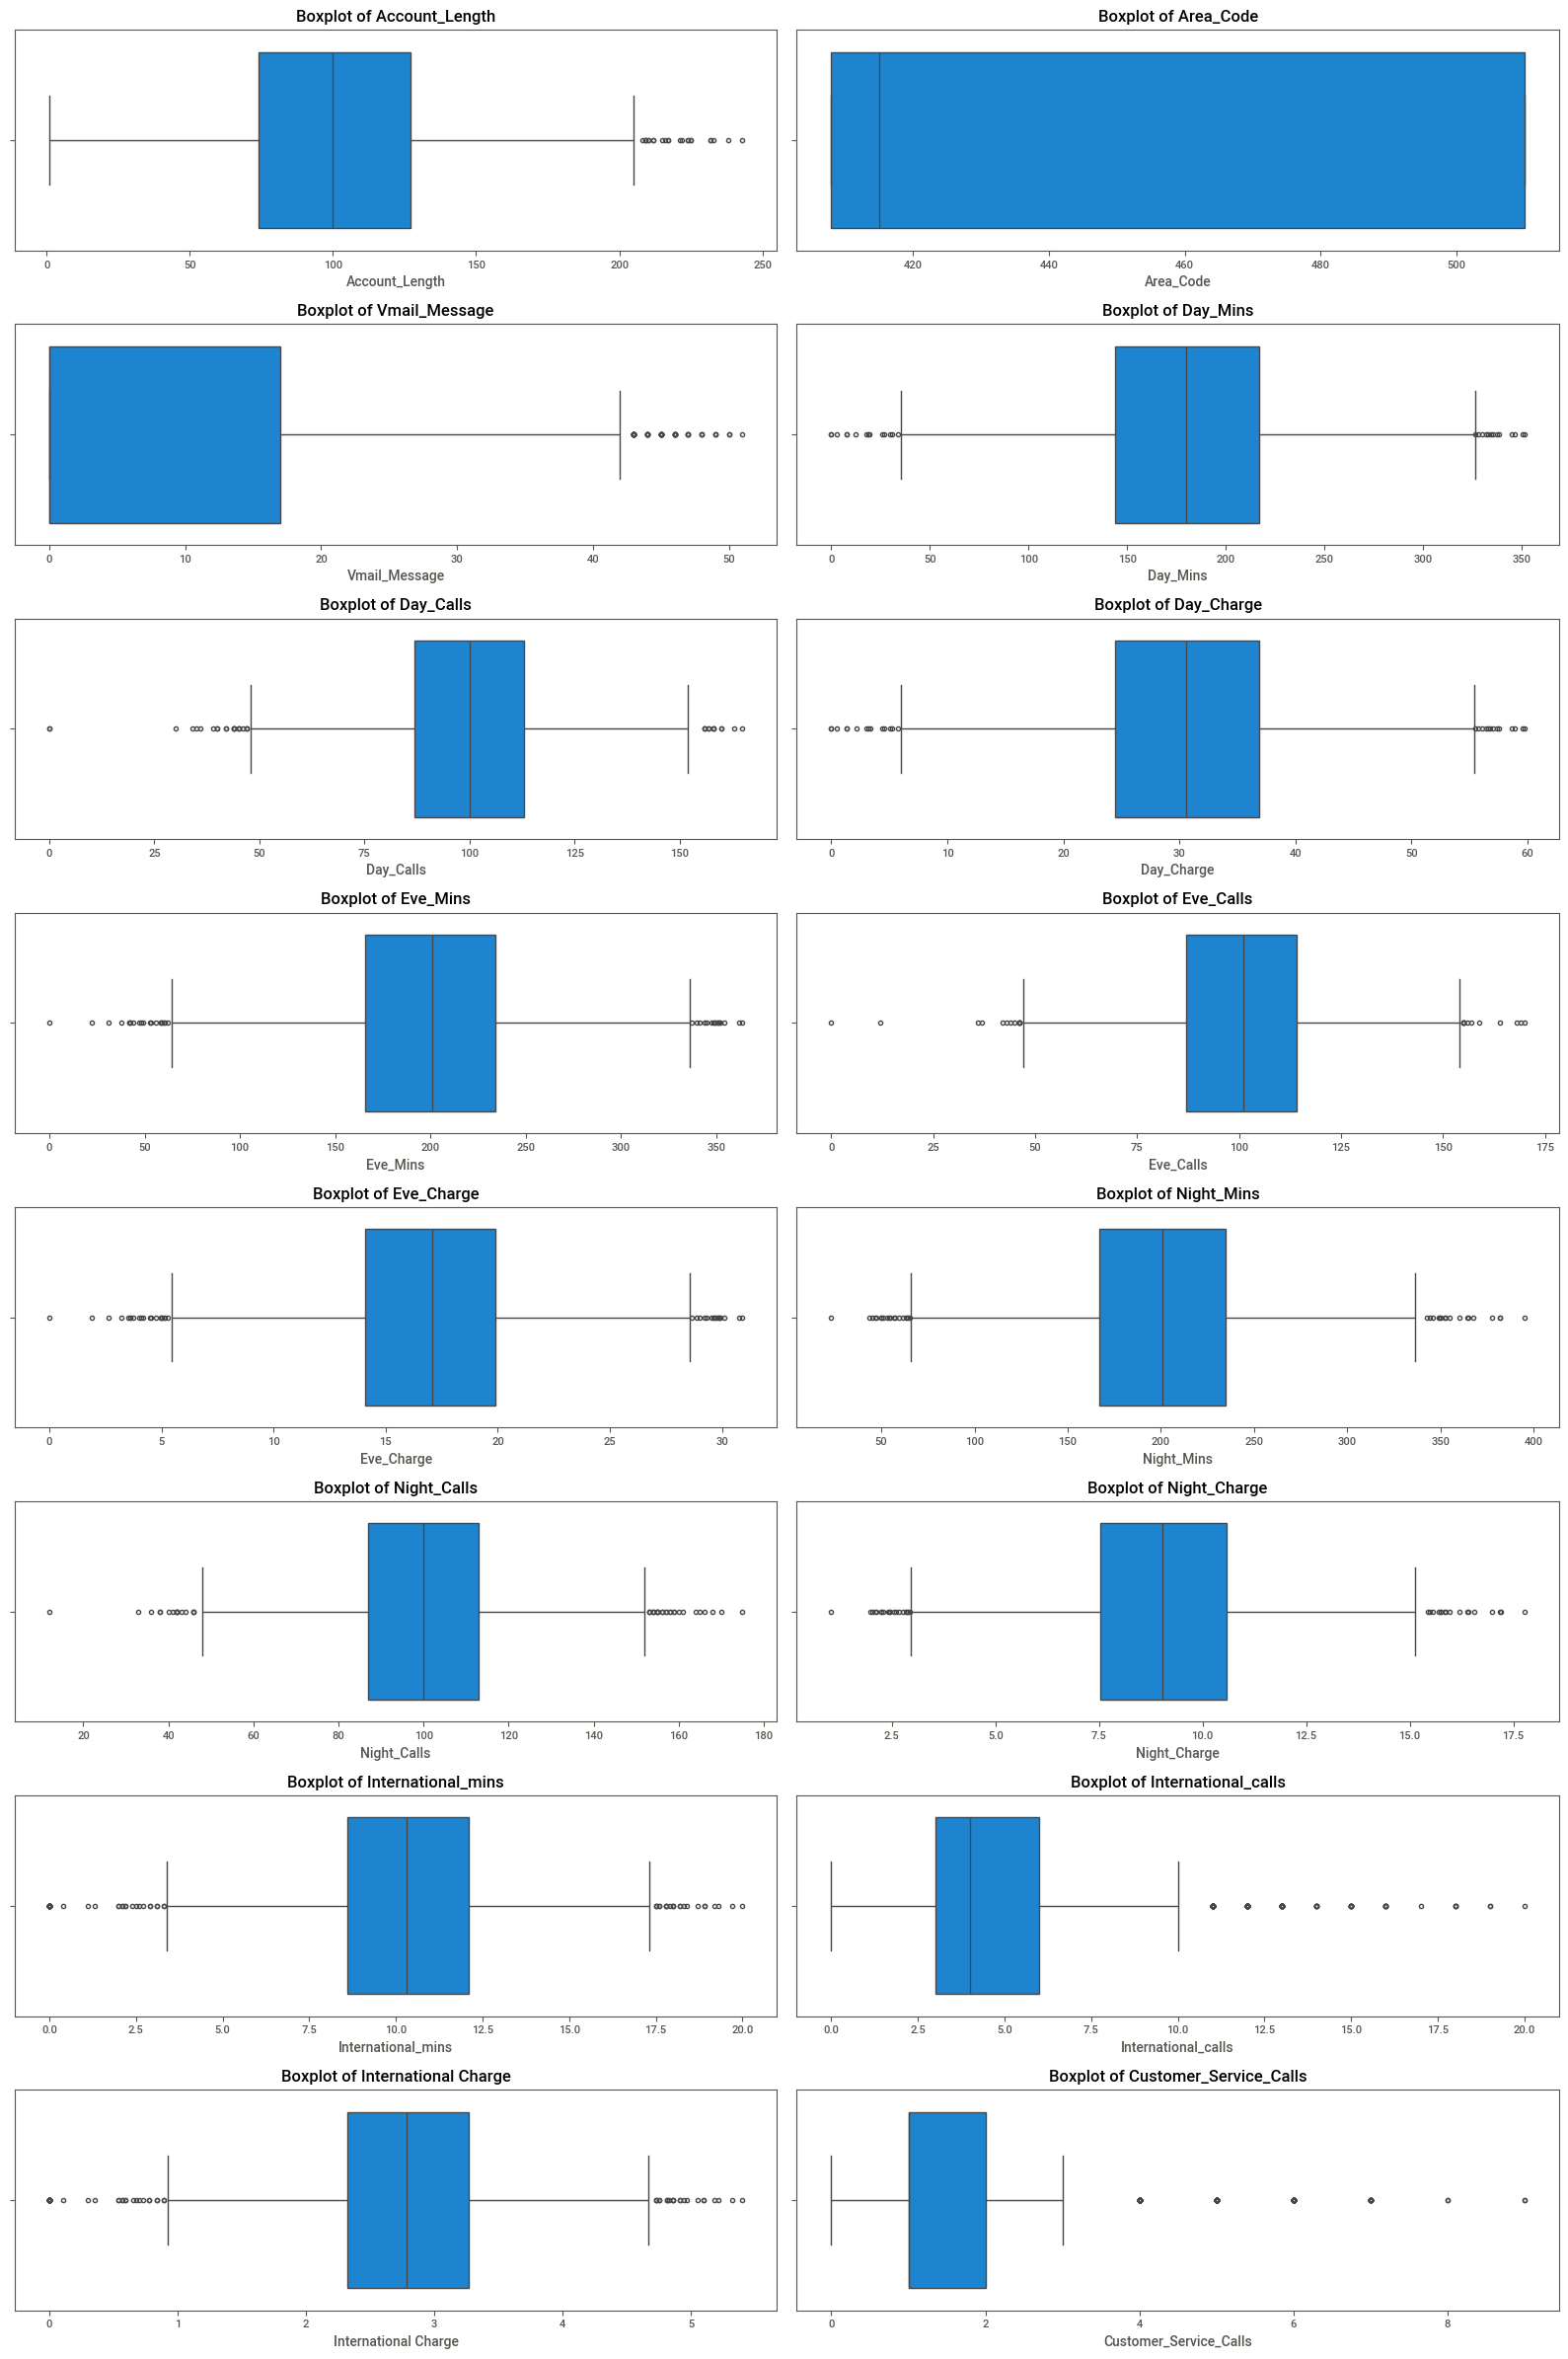

In [ ]:
plt.figure(figsize=(16, 24))  # Adjust figure size for better layout

for idx, col in enumerate(num_data, 1):
    plt.subplot(8, 2, idx)  # 5 rows, 2 columns layout
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

In order to employ tree-based algorithms, I do not want to deal with outliers. Because feature thresholds, rather than distances or distributions, determine the splitting of these models, they are resistant to outliers.

**Encoding categorical data to numerical data**

In [ ]:
data

,State,Account_Length,Area_Code,Phone,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


Importing Label Encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()

In [ ]:
data['International_plan']=le.fit_transform(data['International_plan'])

In [ ]:
data['VMail_Plan']=le.fit_transform(data['VMail_Plan'])

In [ ]:
data['Churned']=le.fit_transform(data['Churned'])

In [ ]:
data

,State,Account_Length,Area_Code,Phone,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
0,KS,128,415,382-4657,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,371-7191,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,358-1921,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,375-9999,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,330-6626,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,0,1,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,0
4613,NM,177,408,343-6820,0,1,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,0
4614,VT,67,408,338-4794,0,1,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,0
4615,MI,98,415,355-8388,0,1,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,0


**Scaling Numerical Data**

**Importing MINMAX Scaler**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scale=MinMaxScaler()

In [ ]:
data[['Vmail_Message']]=scale.fit_transform(data[['Vmail_Message']])

In [ ]:
data[['Day_Mins']]=scale.fit_transform(data[['Day_Mins']])

In [ ]:
data[['Day_Calls']]=scale.fit_transform(data[['Day_Calls']])

In [ ]:
data[['Day_Charge']]=scale.fit_transform(data[['Day_Charge']])

In [ ]:
data[['Eve_Mins']]=scale.fit_transform(data[['Eve_Mins']])

In [ ]:
data[['Eve_Calls']]=scale.fit_transform(data[['Eve_Calls']])

In [ ]:
data[['Eve_Charge']]=scale.fit_transform(data[['Eve_Charge']])

In [ ]:
data[['Night_Mins']]=scale.fit_transform(data[['Night_Mins']])

In [ ]:
data[['Night_Calls']]=scale.fit_transform(data[['Night_Calls']])

In [ ]:
data[['Night_Charge']]=scale.fit_transform(data[['Night_Charge']])

In [ ]:
data[['International_mins']]=scale.fit_transform(data[['International_mins']])

In [ ]:
data[['International_calls']]=scale.fit_transform(data[['International_calls']])

In [ ]:
data[['International Charge']]=scale.fit_transform(data[['International Charge']])

In [ ]:
data[['Customer_Service_Calls']]=scale.fit_transform(data[['Customer_Service_Calls']])

In [ ]:
data

,State,Account_Length,Area_Code,Phone,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
0,KS,128,415,382-4657,0,1,0.490196,0.754196,0.666667,0.754183,0.542755,0.582353,0.542866,0.595750,0.484663,0.595935,0.500,0.15,0.500000,0.111111,0
1,OH,107,415,371-7191,0,1,0.509804,0.459744,0.745455,0.459672,0.537531,0.605882,0.537690,0.621840,0.558282,0.622236,0.685,0.15,0.685185,0.111111,0
2,NJ,137,415,358-1921,0,0,0.000000,0.692461,0.690909,0.692436,0.333242,0.647059,0.333225,0.374933,0.564417,0.375374,0.610,0.25,0.609259,0.000000,0
3,OH,84,408,375-9999,1,0,0.000000,0.851778,0.430303,0.851740,0.170195,0.517647,0.170171,0.467187,0.472393,0.467424,0.330,0.35,0.329630,0.222222,0
4,OK,75,415,330-6626,1,0,0.000000,0.474253,0.684848,0.474230,0.407754,0.717647,0.407959,0.440290,0.668712,0.440526,0.505,0.15,0.505556,0.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,0,1,0.490196,0.409673,0.490909,0.409639,0.514710,0.658824,0.514720,0.364174,0.674847,0.364614,0.425,0.30,0.425926,0.333333,0
4613,NM,177,408,343-6820,0,1,0.568627,0.537696,0.551515,0.537651,0.833379,0.564706,0.833387,0.377622,0.638037,0.377764,0.785,0.05,0.785185,0.333333,0
4614,VT,67,408,338-4794,0,1,0.647059,0.362731,0.763636,0.362784,0.814133,0.758824,0.814300,0.477945,0.484663,0.478183,0.650,0.15,0.650000,0.111111,0
4615,MI,98,415,355-8388,0,1,0.450980,0.480512,0.593939,0.480422,0.622216,0.688235,0.622452,0.382733,0.515337,0.383144,0.715,0.15,0.714815,0.000000,0


**Dropping unwanted columns**

In [ ]:
data.drop(['State', 'Phone', 'Area_Code','Account_Length'], axis=1, inplace=True)

# Balancing the data

**Using SMOTE**

In [ ]:
# calculate the Target Class
data['Churned'].value_counts()

,count
Churned,
0,3961
1,656


Since it is evident that the target class is not balanced, we use the SMOTE method to balance the data.

In [ ]:
# Create X & Y Variable for SMOTE
x = data.drop('Churned',axis=1)
y = data['Churned']

In [ ]:
from imblearn.over_sampling import SMOTE                                # import SMOTE from oversampling
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
x_train_smot, y_train_smot = smote.fit_resample(x_train, y_train)

In [ ]:
y_train_smot.value_counts()

,count
Churned,
0,3168
1,3168


Now data is balanced

In [ ]:
# Create a data frame using Two SMOTE values
data = pd.concat([x_train_smot, y_train_smot], axis=1)


In [ ]:
data

,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
0,0,1,0.274510,0.850071,0.557576,0.850067,0.569975,0.505882,0.570042,0.631253,0.325153,0.631799,0.595000,0.200000,0.594444,0.555556,0
1,0,1,0.607843,0.234139,0.636364,0.234103,0.704152,0.535294,0.704303,0.555137,0.527607,0.555290,0.590000,0.100000,0.590741,0.666667,1
2,0,0,0.000000,0.407112,0.842424,0.407129,0.658785,0.517647,0.659010,0.533889,0.680982,0.534369,0.355000,0.250000,0.355556,0.222222,0
3,1,0,0.000000,0.380370,0.272727,0.380355,0.516360,0.629412,0.516338,0.426842,0.472393,0.427376,0.535000,0.100000,0.535185,0.111111,1
4,0,0,0.000000,0.681650,0.727273,0.681560,0.633214,0.647059,0.633452,0.349112,0.429448,0.349671,0.430000,0.150000,0.429630,0.111111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6331,0,0,0.000000,0.856959,0.534352,0.856876,0.493202,0.509318,0.493389,0.308858,0.531935,0.308870,0.550749,0.250000,0.550875,0.111111,1
6332,0,0,0.000000,0.867984,0.642397,0.867961,0.516902,0.676433,0.516977,0.570725,0.638023,0.570819,0.425011,0.249966,0.425937,0.000000,1
6333,0,0,0.000000,0.375919,0.747878,0.375853,0.586489,0.570206,0.586569,0.389875,0.507393,0.389961,0.568600,0.195750,0.569092,0.453889,1
6334,0,0,0.000000,0.389734,0.620662,0.389730,0.584579,0.593001,0.584628,0.462636,0.695167,0.462844,0.506097,0.107806,0.505501,0.555556,1


# Feature Selection

**Check Correlation**

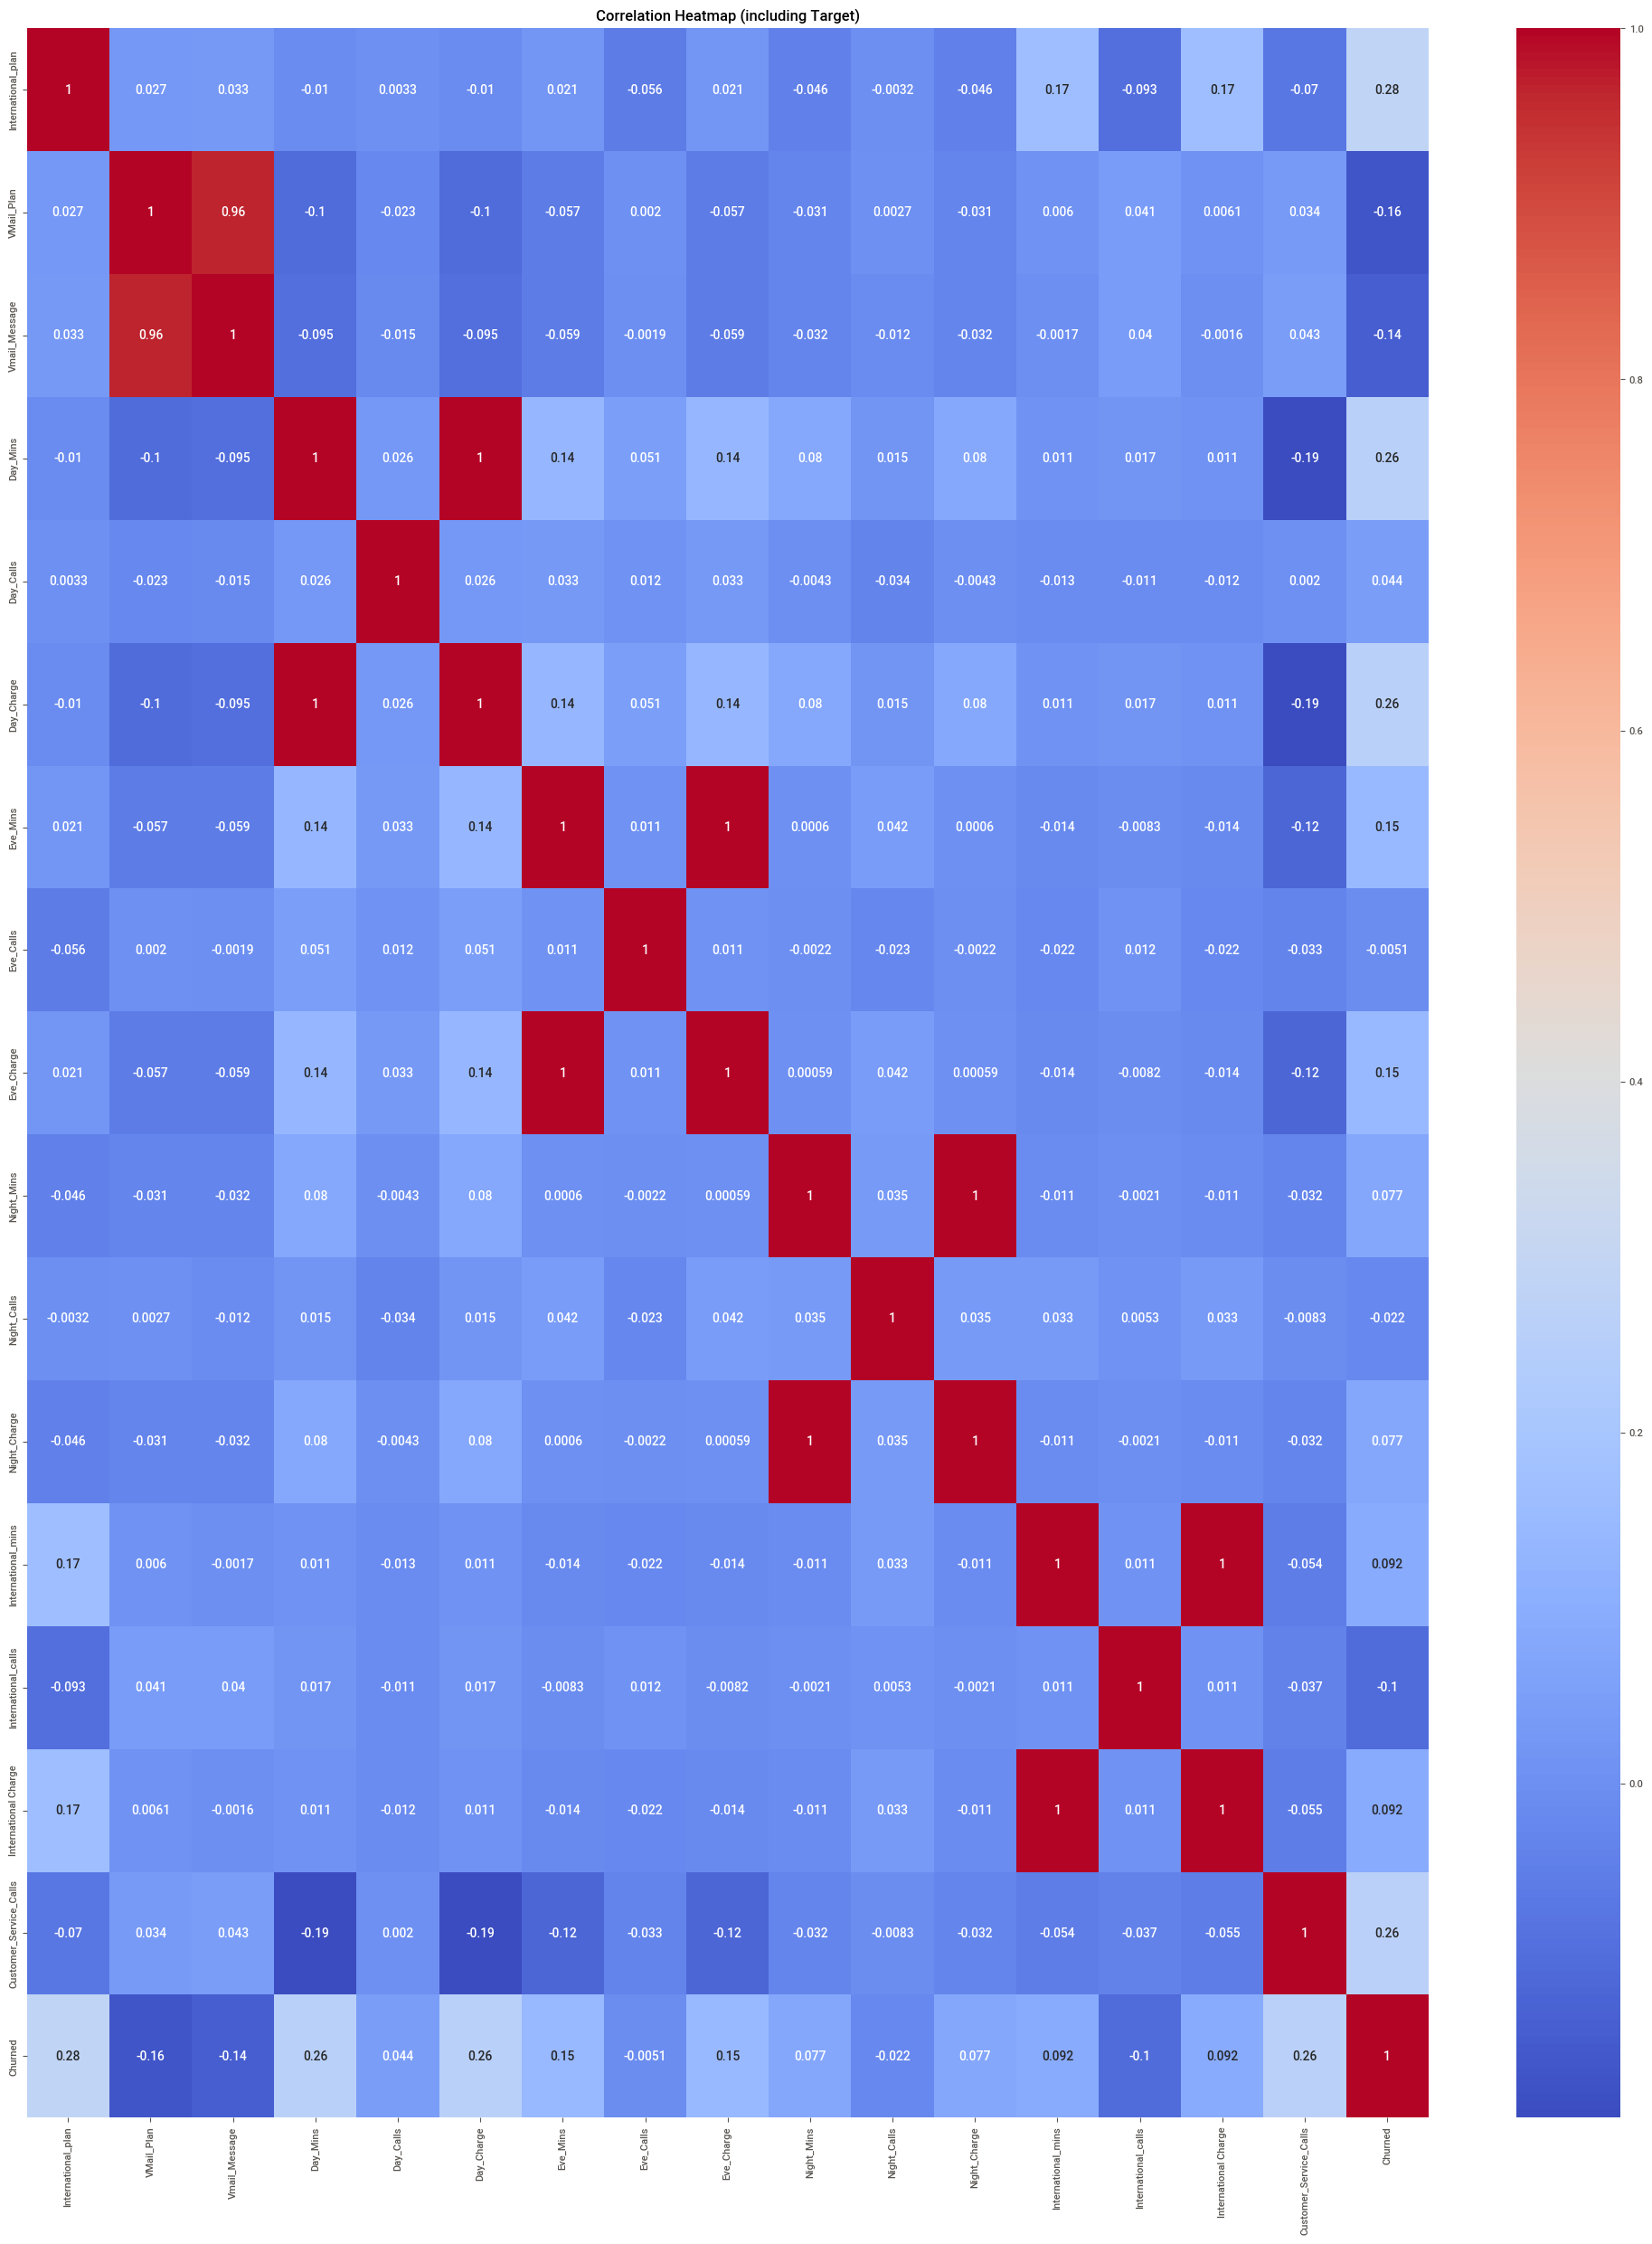

In [ ]:
plt.figure(figsize=(25, 30))  # Set large canvas size for readability
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')  # Optional: add a color map
plt.title("Correlation Heatmap (including Target)")
plt.show()


In [ ]:
import numpy as np
# Create correlation matrix
corr_matrix = data.corr().abs()
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Highly correlated features to consider dropping:", to_drop)


Highly correlated features to consider dropping: ['Vmail_Message', 'Day_Charge', 'Eve_Charge', 'Night_Charge', 'International Charge']


In [ ]:
data['Day_Charge'].corr(data['Day_Mins'])  # Result will be nearly 1.0


np.float64(0.9999999650612293)

In [ ]:
data['Eve_Charge'].corr(data['Eve_Mins'])  # Result will be nearly 1.0


np.float64(0.9999997990839072)

In [ ]:
data['Night_Charge'].corr(data['Night_Mins'])  # Result will be nearly 1.0


np.float64(0.9999992168778591)

In [ ]:
data['International Charge'].corr(data['International_mins'])  # Result will be nearly 1.0


np.float64(0.9999930494996687)

In [ ]:
data

,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_mins,International_calls,International Charge,Customer_Service_Calls,Churned
0,0,1,0.274510,0.850071,0.557576,0.850067,0.569975,0.505882,0.570042,0.631253,0.325153,0.631799,0.595000,0.200000,0.594444,0.555556,0
1,0,1,0.607843,0.234139,0.636364,0.234103,0.704152,0.535294,0.704303,0.555137,0.527607,0.555290,0.590000,0.100000,0.590741,0.666667,1
2,0,0,0.000000,0.407112,0.842424,0.407129,0.658785,0.517647,0.659010,0.533889,0.680982,0.534369,0.355000,0.250000,0.355556,0.222222,0
3,1,0,0.000000,0.380370,0.272727,0.380355,0.516360,0.629412,0.516338,0.426842,0.472393,0.427376,0.535000,0.100000,0.535185,0.111111,1
4,0,0,0.000000,0.681650,0.727273,0.681560,0.633214,0.647059,0.633452,0.349112,0.429448,0.349671,0.430000,0.150000,0.429630,0.111111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6331,0,0,0.000000,0.856959,0.534352,0.856876,0.493202,0.509318,0.493389,0.308858,0.531935,0.308870,0.550749,0.250000,0.550875,0.111111,1
6332,0,0,0.000000,0.867984,0.642397,0.867961,0.516902,0.676433,0.516977,0.570725,0.638023,0.570819,0.425011,0.249966,0.425937,0.000000,1
6333,0,0,0.000000,0.375919,0.747878,0.375853,0.586489,0.570206,0.586569,0.389875,0.507393,0.389961,0.568600,0.195750,0.569092,0.453889,1
6334,0,0,0.000000,0.389734,0.620662,0.389730,0.584579,0.593001,0.584628,0.462636,0.695167,0.462844,0.506097,0.107806,0.505501,0.555556,1


 Now drop the highly correlated features from SMOTE-resampled data

In [ ]:
to_drop = ['Day_Charge', 'Eve_Charge', 'Night_Charge', 'International Charge']
x_train_smot = x_train_smot.drop(to_drop, axis=1)

In [ ]:
x_train_smot

,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Eve_Mins,Eve_Calls,Night_Mins,Night_Calls,International_mins,International_calls,Customer_Service_Calls
0,0,1,0.274510,0.850071,0.557576,0.569975,0.505882,0.631253,0.325153,0.595000,0.200000,0.555556
1,0,1,0.607843,0.234139,0.636364,0.704152,0.535294,0.555137,0.527607,0.590000,0.100000,0.666667
2,0,0,0.000000,0.407112,0.842424,0.658785,0.517647,0.533889,0.680982,0.355000,0.250000,0.222222
3,1,0,0.000000,0.380370,0.272727,0.516360,0.629412,0.426842,0.472393,0.535000,0.100000,0.111111
4,0,0,0.000000,0.681650,0.727273,0.633214,0.647059,0.349112,0.429448,0.430000,0.150000,0.111111
...,...,...,...,...,...,...,...,...,...,...,...,...
6331,0,0,0.000000,0.856959,0.534352,0.493202,0.509318,0.308858,0.531935,0.550749,0.250000,0.111111
6332,0,0,0.000000,0.867984,0.642397,0.516902,0.676433,0.570725,0.638023,0.425011,0.249966,0.000000
6333,0,0,0.000000,0.375919,0.747878,0.586489,0.570206,0.389875,0.507393,0.568600,0.195750,0.453889
6334,0,0,0.000000,0.389734,0.620662,0.584579,0.593001,0.462636,0.695167,0.506097,0.107806,0.555556


In [ ]:
x_train_smot

,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Eve_Mins,Eve_Calls,Night_Mins,Night_Calls,International_mins,International_calls,Customer_Service_Calls
0,0,1,0.274510,0.850071,0.557576,0.569975,0.505882,0.631253,0.325153,0.595000,0.200000,0.555556
1,0,1,0.607843,0.234139,0.636364,0.704152,0.535294,0.555137,0.527607,0.590000,0.100000,0.666667
2,0,0,0.000000,0.407112,0.842424,0.658785,0.517647,0.533889,0.680982,0.355000,0.250000,0.222222
3,1,0,0.000000,0.380370,0.272727,0.516360,0.629412,0.426842,0.472393,0.535000,0.100000,0.111111
4,0,0,0.000000,0.681650,0.727273,0.633214,0.647059,0.349112,0.429448,0.430000,0.150000,0.111111
...,...,...,...,...,...,...,...,...,...,...,...,...
6331,0,0,0.000000,0.856959,0.534352,0.493202,0.509318,0.308858,0.531935,0.550749,0.250000,0.111111
6332,0,0,0.000000,0.867984,0.642397,0.516902,0.676433,0.570725,0.638023,0.425011,0.249966,0.000000
6333,0,0,0.000000,0.375919,0.747878,0.586489,0.570206,0.389875,0.507393,0.568600,0.195750,0.453889
6334,0,0,0.000000,0.389734,0.620662,0.584579,0.593001,0.462636,0.695167,0.506097,0.107806,0.555556


Also drop same features from test data

In [ ]:
x_test = x_test.drop(to_drop, axis=1)

In [ ]:
x_test

,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Eve_Mins,Eve_Calls,Night_Mins,Night_Calls,International_mins,International_calls,Customer_Service_Calls
1304,0,0,0.000000,0.176102,0.472727,0.722024,0.670588,0.509145,0.601227,0.440,0.10,0.333333
2816,0,0,0.000000,0.750213,0.684848,0.512785,0.605882,0.462883,0.533742,0.915,0.30,0.111111
458,0,1,0.549020,0.542248,0.521212,0.605169,0.717647,0.422539,0.417178,0.300,0.15,0.333333
1994,0,0,0.000000,0.482219,0.581818,0.433324,0.552941,0.201721,0.355828,0.530,0.35,0.000000
3392,0,0,0.000000,0.602845,0.393939,0.617542,0.558824,0.564282,0.423313,0.495,0.15,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...
1216,0,0,0.000000,0.401422,0.509091,0.581248,0.635294,0.216514,0.705521,0.295,0.30,0.333333
4598,0,1,0.470588,0.398862,0.618182,0.467693,0.629412,0.324099,0.552147,0.700,0.05,0.111111
2192,0,0,0.000000,0.434993,0.490909,0.705527,0.482353,0.404519,0.613497,0.265,0.30,0.222222
21,0,0,0.000000,0.177525,0.539394,0.467143,0.711765,0.501345,0.319018,0.285,0.30,0.555556


In [ ]:
x_test

,International_plan,VMail_Plan,Vmail_Message,Day_Mins,Day_Calls,Eve_Mins,Eve_Calls,Night_Mins,Night_Calls,International_mins,International_calls,Customer_Service_Calls
1304,0,0,0.000000,0.176102,0.472727,0.722024,0.670588,0.509145,0.601227,0.440,0.10,0.333333
2816,0,0,0.000000,0.750213,0.684848,0.512785,0.605882,0.462883,0.533742,0.915,0.30,0.111111
458,0,1,0.549020,0.542248,0.521212,0.605169,0.717647,0.422539,0.417178,0.300,0.15,0.333333
1994,0,0,0.000000,0.482219,0.581818,0.433324,0.552941,0.201721,0.355828,0.530,0.35,0.000000
3392,0,0,0.000000,0.602845,0.393939,0.617542,0.558824,0.564282,0.423313,0.495,0.15,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...
1216,0,0,0.000000,0.401422,0.509091,0.581248,0.635294,0.216514,0.705521,0.295,0.30,0.333333
4598,0,1,0.470588,0.398862,0.618182,0.467693,0.629412,0.324099,0.552147,0.700,0.05,0.111111
2192,0,0,0.000000,0.434993,0.490909,0.705527,0.482353,0.404519,0.613497,0.265,0.30,0.222222
21,0,0,0.000000,0.177525,0.539394,0.467143,0.711765,0.501345,0.319018,0.285,0.30,0.555556


# Model Creation and Evaluation

**1. Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_smot, y_train_smot)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(x_test)

**Model evaluation for Decision Tree**

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("-------------------------------------------------------------------")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("-------------------------------------------------------------------")
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_dt))

Confusion Matrix:
 [[720  73]
 [ 33  98]]
-------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93       793
           1       0.57      0.75      0.65       131

    accuracy                           0.89       924
   macro avg       0.76      0.83      0.79       924
weighted avg       0.90      0.89      0.89       924

-------------------------------------------------------------------

Accuracy Score: 0.8852813852813853


**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],                # Splitting criteria
    'max_depth': [3, 5, 10, 15, 20, None],            # Tree depth
    'min_samples_split': [2, 5, 10],                  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],                    # Minimum samples at a leaf node
    'max_features': [None, 'sqrt', 'log2']            # Feature selection method
}

# Initialize Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,                      # 5-fold cross-validation
                           n_jobs=-1,                 # Use all available cores
                           scoring='accuracy',        # Evaluation metric
                           verbose=1)

# Run grid search on SMOTE-resampled data
grid_search.fit(x_train_smot, y_train_smot)

# Best model and parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Use best estimator to predict
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(x_test)

# Final evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred_best))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross-Validation Score: 0.924878311120185
Confusion Matrix:
 [[734  59]
 [ 33  98]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       793
           1       0.62      0.75      0.68       131

    accuracy                           0.90       924
   macro avg       0.79      0.84      0.81       924
weighted avg       0.91      0.90      0.90       924


Accuracy Score: 0.9004329004329005


**2. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_smot, y_train_smot)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(x_test)

**Model Evaluation for Random Forest**

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("------------------------------------------------------------")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("------------------------------------------------------------")
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_rf))

Confusion Matrix:
 [[756  37]
 [ 21 110]]
------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       793
           1       0.75      0.84      0.79       131

    accuracy                           0.94       924
   macro avg       0.86      0.90      0.88       924
weighted avg       0.94      0.94      0.94       924

------------------------------------------------------------

Accuracy Score: 0.9372294372294372


**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Set up grid search
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='f1',  # Focus on F1-score for churned class
                           n_jobs=-1,
                           verbose=1)

# Fit on SMOTE-resampled training data
grid_search.fit(x_train_smot, y_train_smot)

# Best model
print("Best Parameters:\n", grid_search.best_params_)

# Predict using best estimator
best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(x_test)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_tuned))
print("-------------------------------------------------------------------------------")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_tuned))
print("---------------------------------------------------------------------------------------")
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_rf_tuned))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
 {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Confusion Matrix:
 [[764  29]
 [ 23 108]]
-------------------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       793
           1       0.79      0.82      0.81       131

    accuracy                           0.94       924
   macro avg       0.88      0.89      0.89       924
weighted avg       0.94      0.94      0.94       924

---------------------------------------------------------------------------------------

Accuracy Score: 0.9437229437229437


**3. XGBoost**

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train_smot, y_train_smot)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(x_test)

**Model Evaluation for XGBoost**

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("-----------------------------------------------------------------------------")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("----------------------------------------------------------------------------------")
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_xgb))
print("----------------------------------------------------------------------------------")


Confusion Matrix:
 [[771  22]
 [ 31 100]]
-----------------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       793
           1       0.82      0.76      0.79       131

    accuracy                           0.94       924
   macro avg       0.89      0.87      0.88       924
weighted avg       0.94      0.94      0.94       924

----------------------------------------------------------------------------------

Accuracy Score: 0.9426406926406926
----------------------------------------------------------------------------------


**Hyperparameter Tuning**

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Base XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Parameter grid (not too large to save time)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,              # You can increase to 50–100 if you want better results
    scoring='f1',           # or 'roc_auc' for better class balance awareness
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit on SMOTE-transformed data
random_search.fit(x_train_smot, y_train_smot)

# Best model
best_xgb = random_search.best_estimator_

# Predict and evaluate
y_pred = best_xgb.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

# Print best parameters
print("\nBest Parameters:", random_search.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Confusion Matrix:
[[766  27]
 [ 27 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       793
           1       0.79      0.79      0.79       131

    accuracy                           0.94       924
   macro avg       0.88      0.88      0.88       924
weighted avg       0.94      0.94      0.94       924


Accuracy Score: 0.9415584415584416

Best Parameters: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1.0}


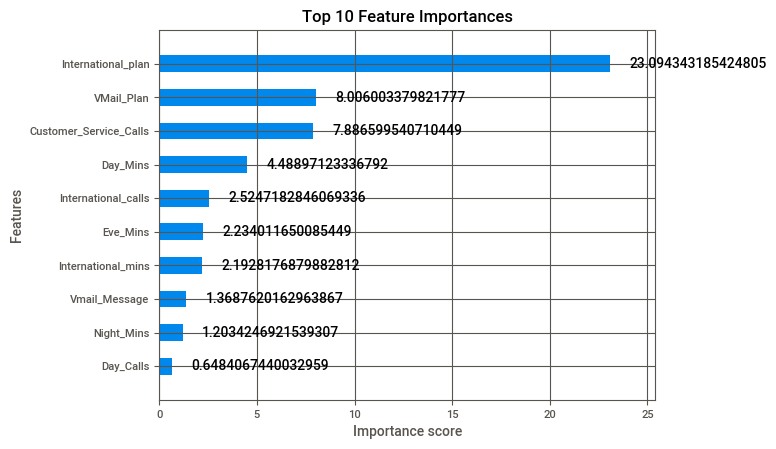

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(best_xgb, max_num_features=10, importance_type='gain', height=0.5)
plt.title("Top 10 Feature Importances")
plt.show()



# Comparing Models

In [ ]:
# Collect performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_scores = {
    'Decision Tree (Tuned)': {
        'Accuracy': accuracy_score(y_test, y_pred_best),
        'Precision': precision_score(y_test, y_pred_best),
        'Recall': recall_score(y_test, y_pred_best),
        'F1 Score': f1_score(y_test, y_pred_best)
    },
    'Random Forest (Tuned)': {
        'Accuracy': accuracy_score(y_test, y_pred_rf_tuned),
        'Precision': precision_score(y_test, y_pred_rf_tuned),
        'Recall': recall_score(y_test, y_pred_rf_tuned),
        'F1 Score': f1_score(y_test, y_pred_rf_tuned)
    },
    'XGBoost (Tuned)': {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }
}

# Convert to DataFrame
results_df = pd.DataFrame(model_scores).T

# Sort by F1 Score or your preferred metric
results_df_sorted = results_df.sort_values(by='F1 Score', ascending=False)
print(results_df_sorted)


                       Accuracy  Precision    Recall  F1 Score
Random Forest (Tuned)  0.943723   0.788321  0.824427  0.805970
XGBoost (Tuned)        0.941558   0.793893  0.793893  0.793893
Decision Tree (Tuned)  0.900433   0.624204  0.748092  0.680556


#### XGBOOST IS THE BEST MODEL

- It has the highest F1 Score (0.7849) — which balances precision and recall, especially important in churn problems.
- It also has the best accuracy and highest precision — meaning fewer false positives (you’re not wrongly flagging loyal customers as churned).
- Recall is strong too — meaning it's catching most of the actual churners.

**Churn Risk Scores**

Creating Churn risk scores that can be indicative to drive retention campaigns.

In [ ]:
# Get churn probabilities for class 1 (churned)
churn_probs = best_xgb.predict_proba(x_test)[:, 1]  # class '1' is usually churn

# Create Churn Risk Score (0–100 scale)
churn_risk_score = np.round(churn_probs * 100, 2)  # Round to 2 decimal places

# Create a result DataFrame
churn_results = pd.DataFrame({

    'Churn_Risk_Score (%)': churn_risk_score,
    'Predicted_Churn_Flag': best_xgb.predict(x_test),  # 0 = No churn, 1 = Churn
    'Actual_Churn': y_test.values
})

# Optional: Sort customers by highest risk
churn_results = churn_results.sort_values(by='Churn_Risk_Score (%)', ascending=False)

# View top 10 high-risk customers
print(churn_results.head(10))

     Churn_Risk_Score (%)  Predicted_Churn_Flag  Actual_Churn
361             99.989998                     1             1
792             99.989998                     1             1
91              99.989998                     1             1
635             99.989998                     1             1
621             99.980003                     1             1
41              99.980003                     1             1
36              99.980003                     1             1
794             99.970001                     1             1
860             99.970001                     1             1
593             99.970001                     1             1


> 💡 **CHURN RISK SCORE TABLE**

| **Churn Risk Score (%)** | **Suggested Action** |
|--------------------------|----------------------|
| **80%–100%**                 | **Urgent retention campaign (discounts, personal calls)** |
| **50%–79%**                  | **Target with proactive support (check-ins, loyalty points)** |
| **< 50%**                    | **Monitor and nurture** |


**Introducing new predicting variable “CHURN-FLAG” with values YES(1) or NO(0) so that email campaigns with lucrative offers can be targeted to Churn YES customers**

In [ ]:
# Predict churn (0 = No churn, 1 = Churn)
y_pred_churn = best_xgb.predict(x_test)

# Create CHURN-FLAG column based on prediction
churn_flag = np.where(y_pred_churn == 1, 'YES', 'NO')  # YES for churned customers

# Build final DataFrame
churn_campaign_df = pd.DataFrame({

    'Churn_Risk_Score (%)': np.round(best_xgb.predict_proba(x_test)[:, 1] * 100, 2),
    'CHURN-FLAG': churn_flag
})

# Optional: Add actual churn for evaluation (if you want)
churn_campaign_df['Actual_Churn'] = y_test.values

# View some samples
print(churn_campaign_df.head())


   Churn_Risk_Score (%) CHURN-FLAG  Actual_Churn
0              0.050000         NO             0
1             49.080002         NO             1
2              0.040000         NO             0
3              1.040000         NO             0
4              0.490000         NO             0


In [ ]:
churn_campaign_df.tail()

**Identify churn-prone customers (CHURN-FLAG = YES) and build internal flags to help drive retention activities**

In [ ]:
# Define retention action logic based on churn risk score
def retention_action(score):
    if score >= 70:
        return "High"    # Urgent retention campaign
    elif score >= 50:
        return "Medium"  # Proactive support
    else:
        return "Low"     # Monitor and nurture

# Apply the logic to your DataFrame
churn_campaign_df["retention_follow"] = churn_campaign_df["Churn_Risk_Score (%)"].apply(retention_action)


In [ ]:
churn_campaign_df

,Churn_Risk_Score (%),CHURN-FLAG,Actual_Churn,retention_follow
0,0.050000,NO,0,Low
1,49.080002,NO,1,Low
2,0.040000,NO,0,Low
3,1.040000,NO,0,Low
4,0.490000,NO,0,Low
...,...,...,...,...
919,0.070000,NO,0,Low
920,0.870000,NO,0,Low
921,0.030000,NO,0,Low
922,99.949997,YES,1,High


In [ ]:
# Save to CSV
churn_campaign_df.to_csv('churn_campaign_output.csv', index=False)

print("File saved as churn_campaign_output.csv")


File saved as churn_campaign_output.csv


# Retention Advice Based on Churn Risk

 <h5>
 <details>
 <summary> High-Risk Customers (CHURN-FLAG = YES, Score > 70%) </summary>

 - Assign dedicated customer care agents.
 - Auto-prioritize their support tickets (flag as high priority).
 - Send exclusive offers (e.g., discounts, cashbacks, free upgrades).
 - Run win-back email/SMS campaigns with urgent messaging.
 - Request quick feedback surveys to identify dissatisfaction.
 - Fast resolution of complaints and service issues.
 - Eg. 30% off next recharge, 3 months free OTT access, or exclusive postpaid upgrade.
 </details>

 <details>
    <summary> Medium-Risk Customers (Churn Risk Score 50–70%) </summary>

 - Send engagement reminders (emails, app notifications).
 - Conduct customer success calls or product walkthroughs.
 - Offer small loyalty rewards (e.g., coupons, cashback).
 - Flag for preemptive support if any complaints are open  
</details>

<details>
    <summary> Low-Risk Customers (Churn Risk Score < 50%) </summary>

 - Send thank-you messages recognizing their loyalty.
 - Launch referral programs for them to bring in new users.
 - Celebrate milestones (e.g., “1 year with us!” perks).
 - Continue top-quality support to maintain satisfaction.  
</details>
</h5>